In [42]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Базовая работа с изображением

In [43]:
image = cv2.imread('sar_2_color.jpg')

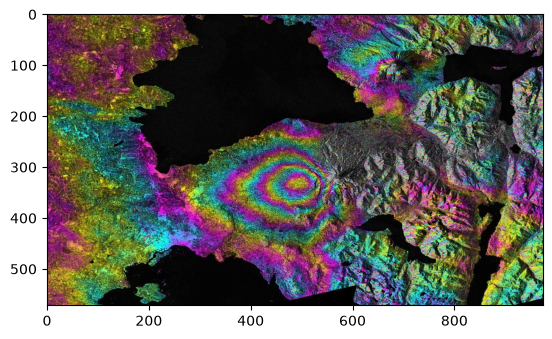

In [44]:
plt.imshow(image)

In [45]:
image.shape # h,w,c

(572, 974, 3)

In [46]:
image[250,250] # b,g,r

array([12, 12, 12], dtype=uint8)

In [47]:
# ROI
img_roi = image[100:200, 500:700]

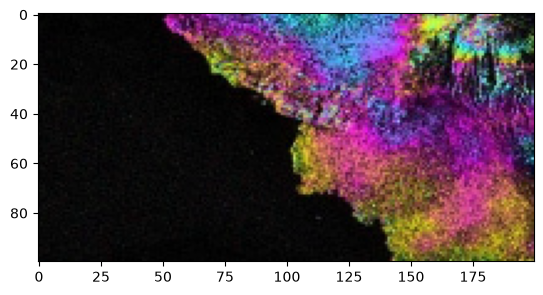

In [48]:
plt.imshow(img_roi)

In [49]:
b,g,r = cv2.split(image)

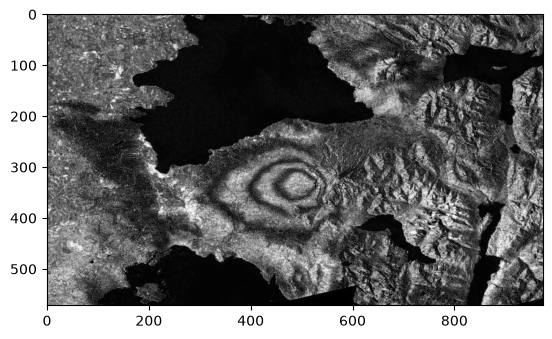

In [50]:
plt.imshow(b, cmap = 'gray')

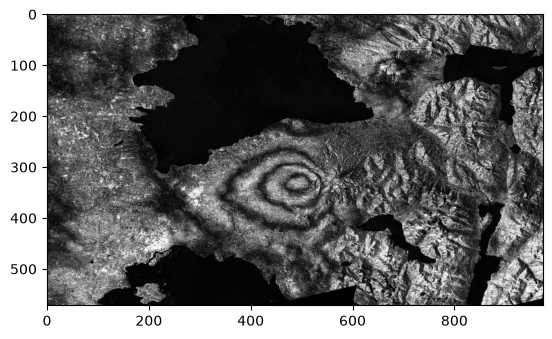

In [51]:
plt.imshow(g, cmap = 'gray')

In [52]:
# alternative approach
b = image[:,:,0]

In [53]:
import copy

image2 = copy.deepcopy(image)

In [54]:
image2[50:100,50:100] = [0,0,0]

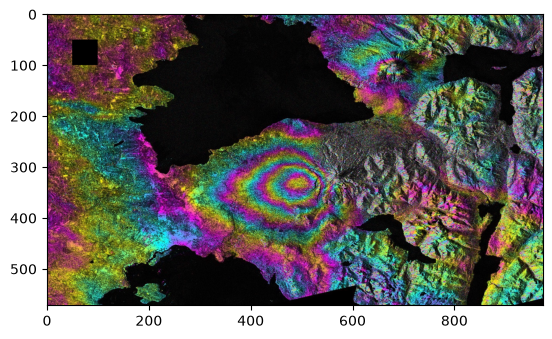

In [55]:
plt.imshow(image2)

In [56]:
# empty image
image_template = np.zeros(image.shape,np.uint8)

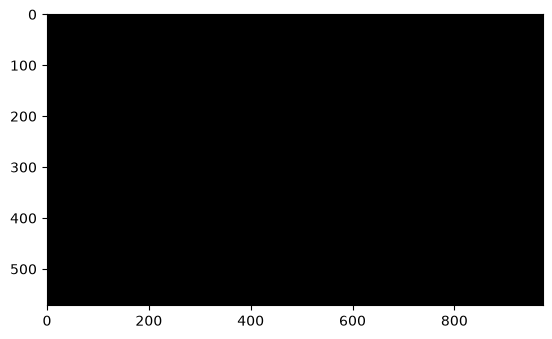

In [57]:
plt.imshow(image_template)

# Конвертация цветовых моделей

In [58]:
image_template[0,0]

array([0, 0, 0], dtype=uint8)

In [59]:
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

In [60]:
image_gray[0,0]

np.uint8(40)

In [61]:
image_gray.shape

(572, 974)

In [62]:
image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV) 

In [63]:
image_hsv.shape

(572, 974, 3)

In [64]:
image_hsv[0,0]

array([117, 143,  75], dtype=uint8)

In [65]:
image[0,0]

array([75, 37, 33], dtype=uint8)

In [66]:
image_lab = cv2.cvtColor(image, cv2.COLOR_BGR2Lab)

In [67]:
image_lab[0,0]

array([ 42, 139, 104], dtype=uint8)

# Пороговая фильтрация

In [68]:
_,thresh1 = cv2.threshold(image_gray,200,255,cv2.THRESH_BINARY)

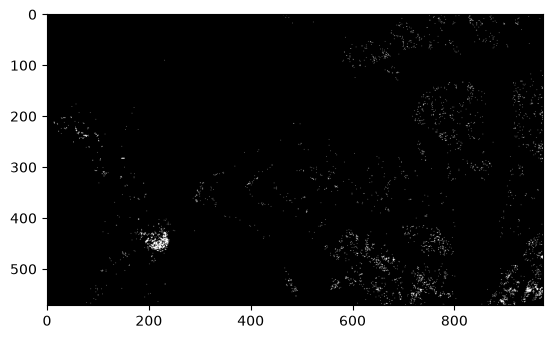

In [69]:
plt.imshow(thresh1, cmap='gray')

In [70]:
thresh1[thresh1==100].sum()

np.uint64(0)

# Построение гистограммы

In [71]:
histSize = 256
histRange = (0, 256)
accumulate = False

b_hist = cv2.calcHist([b], [0], None, [histSize], histRange, accumulate=accumulate)

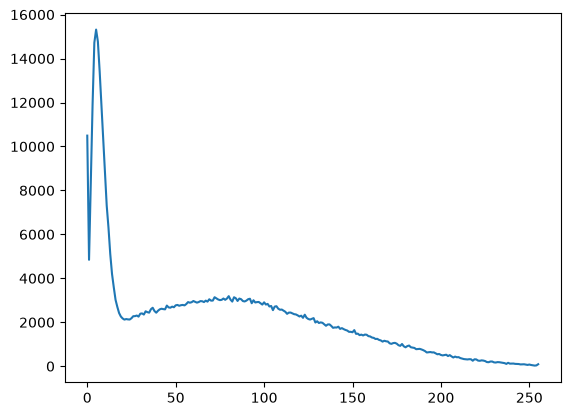

In [72]:
plt.plot(b_hist)

In [73]:
b_hist_cum = b_hist.cumsum()

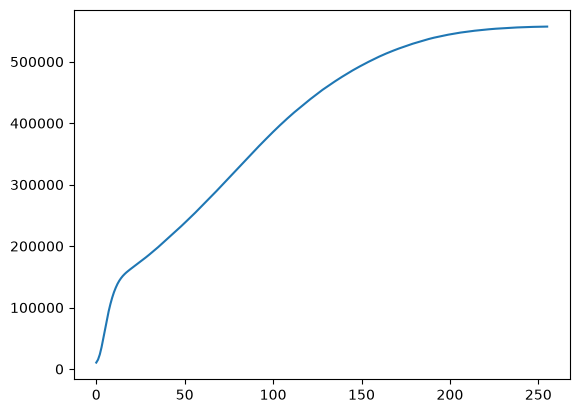

In [74]:
plt.plot(b_hist_cum)

In [75]:
b_hist_norm = b_hist /  (image.shape[0] * image.shape[1])

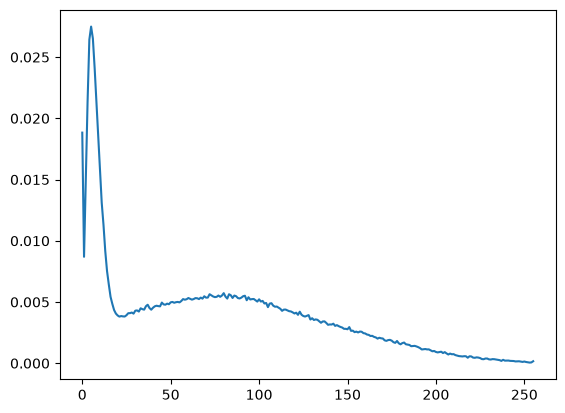

In [76]:
plt.plot(b_hist_norm)

# Сравнение двух изображений

In [77]:
from skimage.metrics import structural_similarity, mean_squared_error

(ssim, diff) = structural_similarity(image_gray, image_gray, full=True)
diff = (diff * 255).astype("uint8")
print("SSIM: {}".format(ssim))

SSIM: 1.0


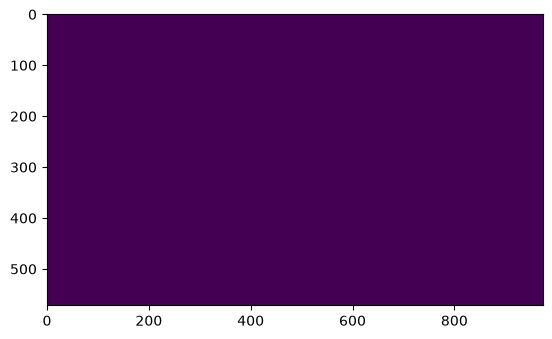

In [78]:
plt.imshow(diff)

In [79]:
mse = mean_squared_error(image_gray, image_gray)
mse

np.float64(0.0)

# Статистические характеристики изображений

In [80]:
mean = image_gray.mean()

In [81]:
std = image_gray.std()

In [82]:
print(mean,std)

67.41225535245043 52.01619187595963


In [83]:
eq_gray = cv2.equalizeHist(image_gray)

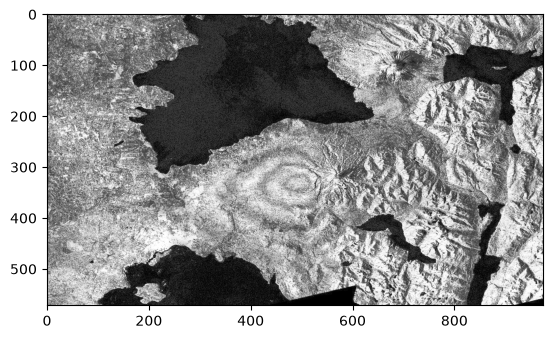

In [84]:
plt.imshow(eq_gray, cmap="gray")


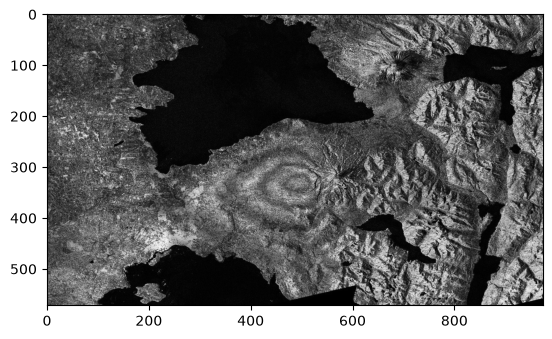

In [85]:
plt.imshow(image_gray, cmap="gray")

# Выполнение задания

Работа выполняется для изображения `sar_1_gray.jpg`. Для сравнения изображений используются MSE и SSIM.

Размер изображения: (400, 600)
Тип данных: uint8
Минимальное значение: 0
Максимальное значение: 255


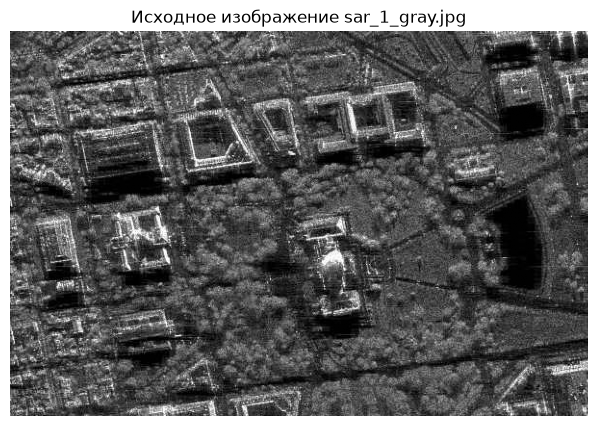

In [86]:
# 1. Загрузка изображения в оттенках серого
gray = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)

if gray is None:
    raise FileNotFoundError('Файл sar_1_gray.jpg не найден')

print('Размер изображения:', gray.shape)
print('Тип данных:', gray.dtype)
print('Минимальное значение:', gray.min())
print('Максимальное значение:', gray.max())

plt.figure(figsize=(8, 5))
plt.imshow(gray, cmap='gray')
plt.title('Исходное изображение sar_1_gray.jpg')
plt.axis('off')
plt.show()

## 2. Гистограмма исходного изображения

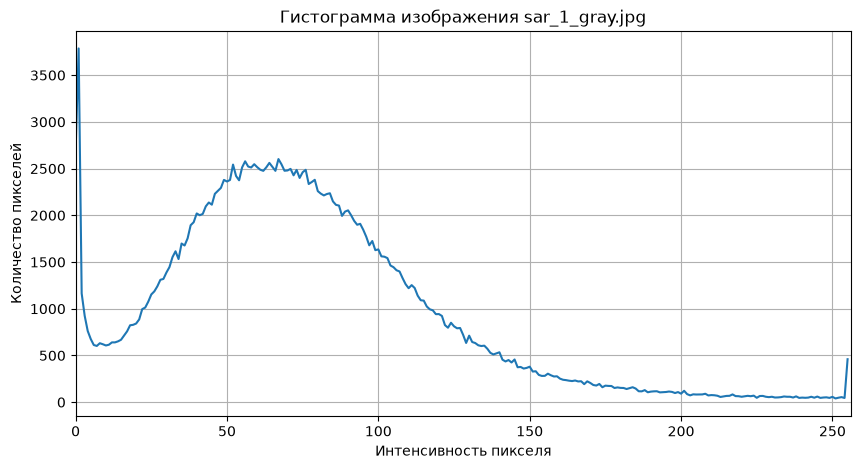

Среднее значение яркости: 74.94157083333333
Среднеквадратичное отклонение: 43.658465466227916


In [87]:
hist = cv2.calcHist([gray], [0], None, [256], [0, 256])

plt.figure(figsize=(10, 5))
plt.plot(hist)
plt.title('Гистограмма изображения sar_1_gray.jpg')
plt.xlabel('Интенсивность пикселя')
plt.ylabel('Количество пикселей')
plt.xlim([0, 256])
plt.grid(True)
plt.show()

print('Среднее значение яркости:', gray.mean())
print('Среднеквадратичное отклонение:', gray.std())

## 3. Гамма-коррекция

Используем преобразование

$$I_{out}=255\left(\frac{I_{in}}{255}\right)^\gamma.$$

При $\gamma < 1$ изображение становится светлее, при $\gamma > 1$ — темнее.

Результат гамма-коррекции:
gamma = 0.5: средняя яркость = 130.56
gamma = 2.0: средняя яркость = 29.07


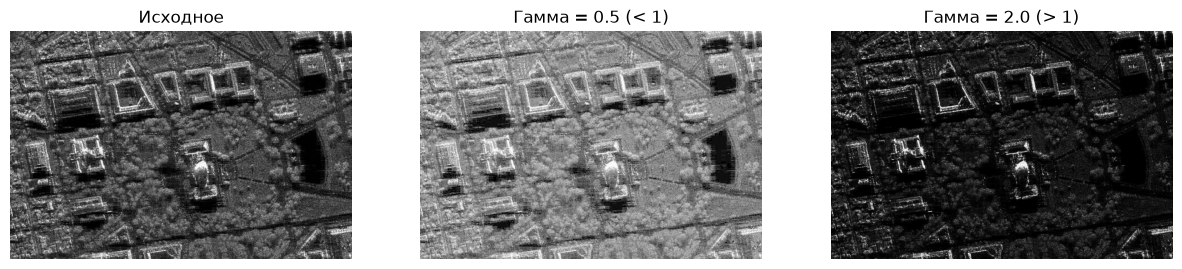

In [88]:
def gamma_correction(image, gamma):
    image_norm = image.astype(np.float32) / 255.0
    corrected = 255.0 * np.power(image_norm, gamma)
    return np.clip(corrected, 0, 255).astype(np.uint8)

gamma_less_1 = 0.5
gamma_greater_1 = 2.0

gamma_img_less_1 = gamma_correction(gray, gamma_less_1)
gamma_img_greater_1 = gamma_correction(gray, gamma_greater_1)

print('Результат гамма-коррекции:')
print(f'gamma = {gamma_less_1}: средняя яркость = {gamma_img_less_1.mean():.2f}')
print(f'gamma = {gamma_greater_1}: средняя яркость = {gamma_img_greater_1.mean():.2f}')

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title('Исходное')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(gamma_img_less_1, cmap='gray')
plt.title(f'Гамма = {gamma_less_1} (< 1)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(gamma_img_greater_1, cmap='gray')
plt.title(f'Гамма = {gamma_greater_1} (> 1)')
plt.axis('off')
plt.show()

## 4. Сравнение исходного изображения и гамма-коррекции: MSE и SSIM

In [89]:
def compare_images(original, corrected, name):
    mse = mean_squared_error(original, corrected)
    ssim = structural_similarity(original, corrected)
    print(f'{name}:')
    print(f'  MSE  = {mse:.4f}')
    print(f'  SSIM = {ssim:.6f}')
    print()
    return mse, ssim

mse_g1, ssim_g1 = compare_images(
    gray, gamma_img_less_1, f'Гамма = {gamma_less_1}'
)

mse_g2, ssim_g2 = compare_images(
    gray, gamma_img_greater_1, f'Гамма = {gamma_greater_1}'
)

print('Интерпретация: MSE показывает среднюю квадратичную ошибку между изображениями,')
print('SSIM показывает структурное сходство; значение SSIM ближе к 1 означает большее сходство.')

Гамма = 0.5:
  MSE  = 3250.4291
  SSIM = 0.787501

Гамма = 2.0:
  MSE  = 2383.7636
  SSIM = 0.527046

Интерпретация: MSE показывает среднюю квадратичную ошибку между изображениями,
SSIM показывает структурное сходство; значение SSIM ближе к 1 означает большее сходство.


## 5. Статистическая цветокоррекция на основе `eq_gray`

В исходном ноутбуке `eq_gray` получается с помощью `cv2.equalizeHist`. Используем его как эталон и приводим среднее и стандартное отклонение исходного изображения к статистике `eq_gray`:

$$I_{corr}=\frac{I-\mu_I}{\sigma_I}\sigma_{eq}+\mu_{eq}.$$

Статистика исходного изображения:
  mean = 74.9416, std = 43.6585
Статистика eq_gray:
  mean = 127.0256, std = 74.2696
Статистика после статистической коррекции:
  mean = 123.1181, std = 65.3026


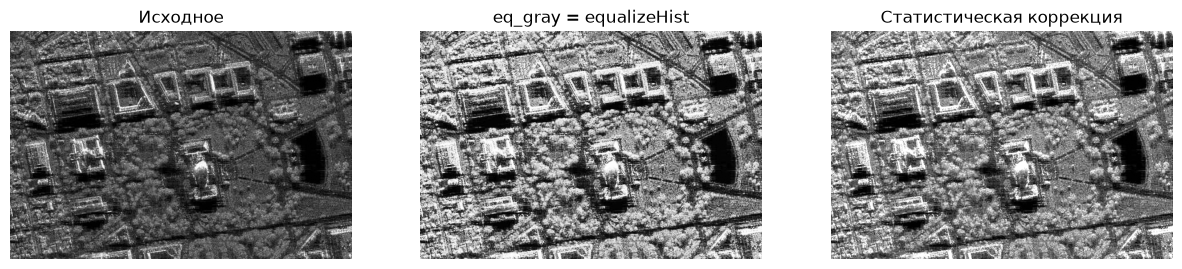

Статистическая коррекция относительно исходного:
  MSE  = 2946.7009
  SSIM = 0.786210



(np.float64(2946.70085), np.float64(0.7862101987758867))

In [90]:
eq_gray = cv2.equalizeHist(gray)

def statistical_correction(image, reference):
    mean_image = image.mean()
    std_image = image.std()
    mean_reference = reference.mean()
    std_reference = reference.std()

    corrected = (image.astype(np.float32) - mean_image) * (std_reference / std_image) + mean_reference
    return np.clip(corrected, 0, 255).astype(np.uint8)

stat_img = statistical_correction(gray, eq_gray)

print('Статистика исходного изображения:')
print(f'  mean = {gray.mean():.4f}, std = {gray.std():.4f}')
print('Статистика eq_gray:')
print(f'  mean = {eq_gray.mean():.4f}, std = {eq_gray.std():.4f}')
print('Статистика после статистической коррекции:')
print(f'  mean = {stat_img.mean():.4f}, std = {stat_img.std():.4f}')

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title('Исходное')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(eq_gray, cmap='gray')
plt.title('eq_gray = equalizeHist')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(stat_img, cmap='gray')
plt.title('Статистическая коррекция')
plt.axis('off')
plt.show()

compare_images(gray, stat_img, 'Статистическая коррекция относительно исходного')

## 6. Пороговая фильтрация с различными параметрами

Порог = 50
  Уникальные значения: [  0 255]
  Белых пикселей: 169178
  Чёрных пикселей: 70822
Порог = 100
  Уникальные значения: [  0 255]
  Белых пикселей: 55653
  Чёрных пикселей: 184347
Порог = 150
  Уникальные значения: [  0 255]
  Белых пикселей: 13083
  Чёрных пикселей: 226917
Порог = 200
  Уникальные значения: [  0 255]
  Белых пикселей: 3830
  Чёрных пикселей: 236170


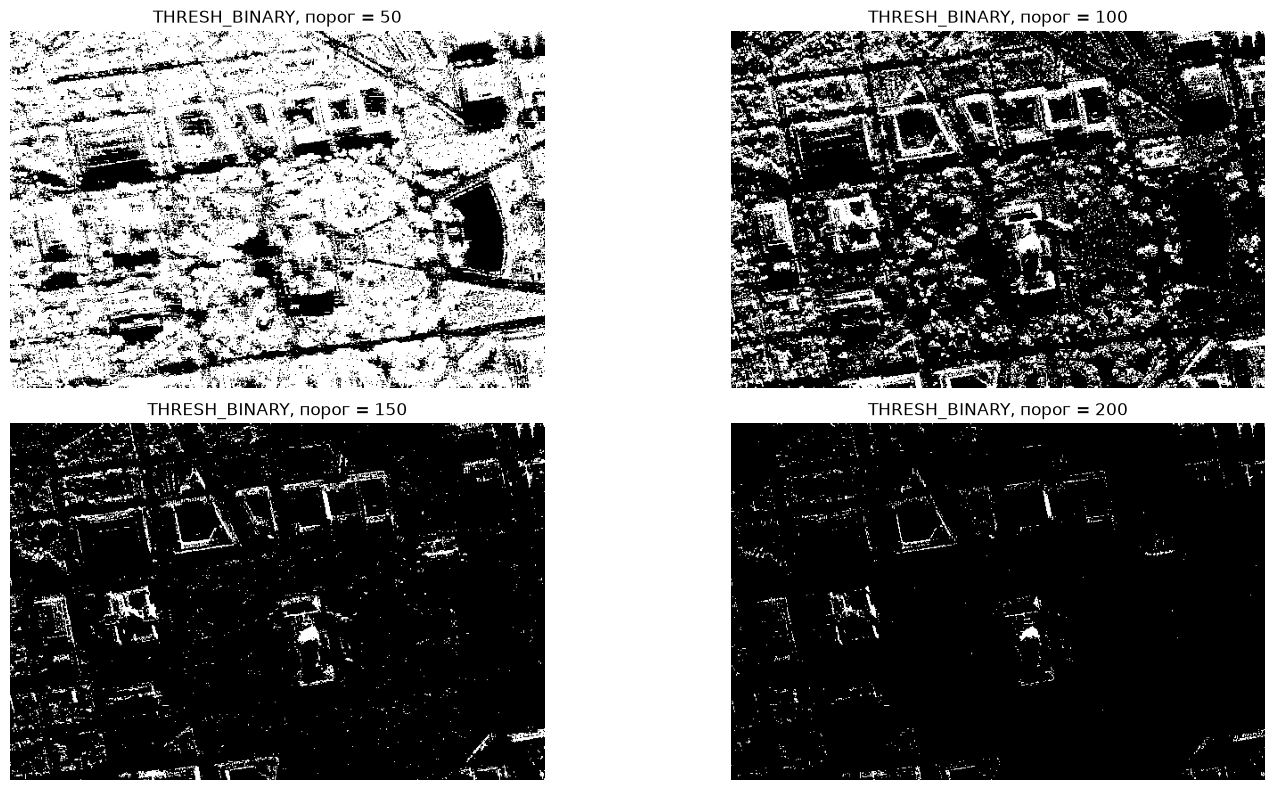

In [91]:
threshold_values = [50, 100, 150, 200]

plt.figure(figsize=(16, 8))
for i, threshold in enumerate(threshold_values, 1):
    _, binary = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)

    print(f'Порог = {threshold}')
    print('  Уникальные значения:', np.unique(binary))
    print('  Белых пикселей:', np.sum(binary == 255))
    print('  Чёрных пикселей:', np.sum(binary == 0))

    plt.subplot(2, 2, i)
    plt.imshow(binary, cmap='gray')
    plt.title(f'THRESH_BINARY, порог = {threshold}')
    plt.axis('off')

plt.tight_layout()
plt.show()

### Дополнительно: сравнение основных режимов пороговой фильтрации

Для одного порога также проверим `BINARY`, `BINARY_INV`, `TRUNC` и `TOZERO`.

BINARY, порог = 128: min=0, max=255
BINARY_INV, порог = 128: min=0, max=255
TRUNC, порог = 128: min=0, max=128
TOZERO, порог = 128: min=0, max=255


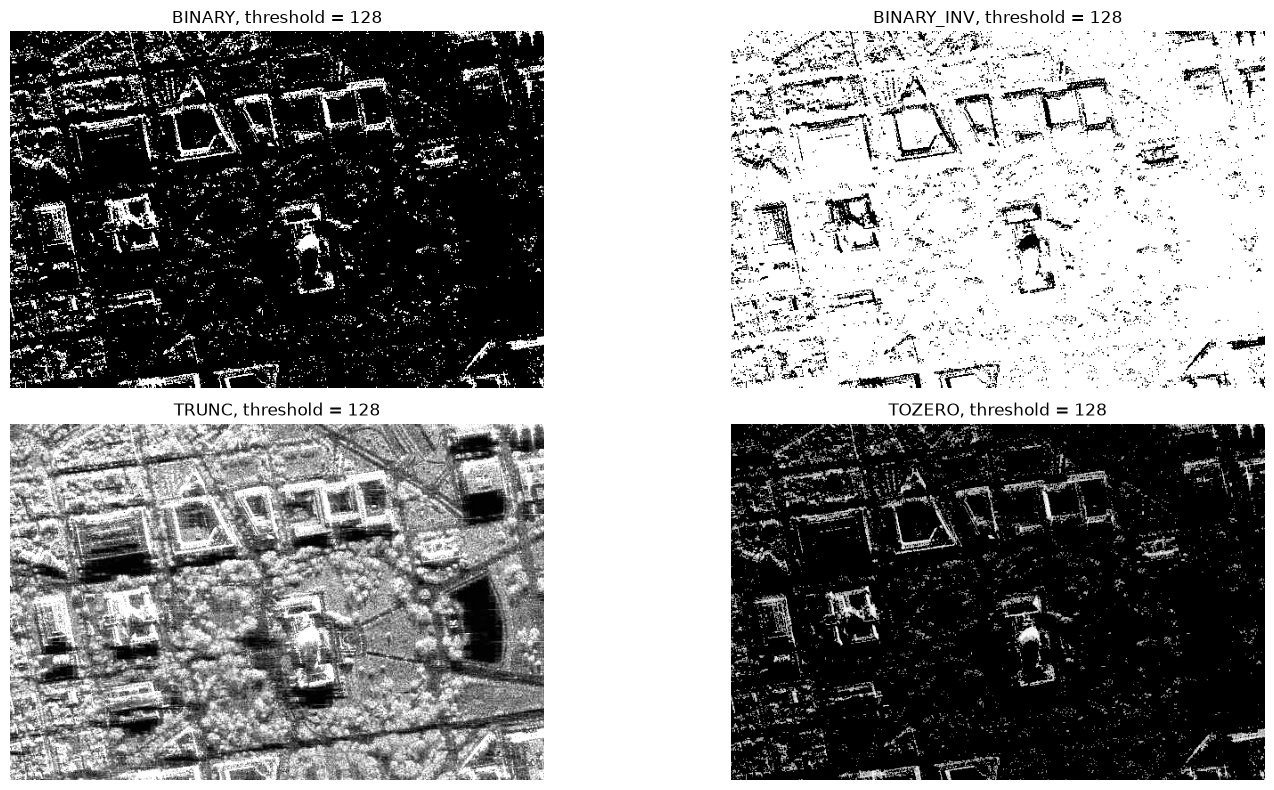

In [92]:
threshold = 128
threshold_modes = [
    ('BINARY', cv2.THRESH_BINARY),
    ('BINARY_INV', cv2.THRESH_BINARY_INV),
    ('TRUNC', cv2.THRESH_TRUNC),
    ('TOZERO', cv2.THRESH_TOZERO)
]

plt.figure(figsize=(16, 8))
for i, (mode_name, mode) in enumerate(threshold_modes, 1):
    _, result = cv2.threshold(gray, threshold, 255, mode)
    print(f'{mode_name}, порог = {threshold}: min={result.min()}, max={result.max()}')

    plt.subplot(2, 2, i)
    plt.imshow(result, cmap='gray')
    plt.title(f'{mode_name}, threshold = {threshold}')
    plt.axis('off')

plt.tight_layout()
plt.show()